# Homework 7: Sentiment Classification with Pre-trained and Re-trained GloVe Embeddings

In this notebook, we continue our investigation of text classification using “Bag of Embeddings” models and the IMDB movie review dataset.

Previously, we used pre-trained GloVe embeddings as fixed feature extractors. In this homework, we move to **fine-tuning** those embeddings — allowing gradient updates to adapt the embedding space to the sentiment classification task.

You will explore how model performance is affected by:

- Fine-tuning vs. frozen embeddings  
- Architectural adjustments  
- Vocabulary size and maximum message length  
- Embedding dimensionality  

You'll complete three problems:

- **Problem One:** Build a baseline model with unfrozen embeddings and experiment with architectural and training adjustments to improve performance.
- **Problem Two:** Investigate how increasing the maximum message length and vocabulary size affects model accuracy and generalization.
- **Problem Three:** Examine the impact of changing the embedding dimension on model performance.

In each problem, you will report your best validation accuracy and reflect on what your experiments reveal about model capacity, generalization, and diminishing returns.

### Useful Imports

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import time
from datetime import datetime
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import imdb
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split


# -----------------------------
# Reproducibility
# -----------------------------
random_seed = 42
np.random.seed(random_seed)
tf.random.set_seed(random_seed)

# -----------------------------
# Utility: format elapsed time
# -----------------------------
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

# Example usage:
# start_time = time.time()
# <your code>
# print("Execution Time:", format_hms(time.time() - start_time))

# Suppress TensorFlow INFO/WARNING messages
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

## GloVe Setup (Auto-Download if Needed)

This notebook will automatically download the GloVe 6B embeddings
if they are not already present (you should have them if you ran the Coding Notebook from Week 7). 

In [2]:
import os, zipfile, urllib.request
from pathlib import Path
import numpy as np
from tensorflow.keras.datasets import imdb

# -----------------------------
# GloVe Setup (auto-download)
# -----------------------------
GLOVE_DIR = Path(os.environ.get("GLOVE_DIR", "data/glove")).expanduser()
GLOVE_DIR.mkdir(parents=True, exist_ok=True)

GLOVE_6B_URL = "https://nlp.stanford.edu/data/glove.6B.zip"

def ensure_glove_6b(download_dir: Path) -> Path:
    zip_path = download_dir / "glove.6B.zip"
    extracted_dir = download_dir / "glove.6B"

    if extracted_dir.exists() and any(extracted_dir.glob("glove.6B.*d.txt")):
        return extracted_dir

    if not zip_path.exists():
        print(f"Downloading GloVe 6B to: {zip_path}")
        urllib.request.urlretrieve(GLOVE_6B_URL, zip_path)

    print(f"Extracting: {zip_path} -> {download_dir}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(download_dir)

    if extracted_dir.exists():
        return extracted_dir
    if any(download_dir.glob("glove.6B.*d.txt")):
        return download_dir

    raise FileNotFoundError("GloVe files not found after extraction.")

def load_glove_vectors(glove_folder: Path, embedding_dimension: int) -> dict:
    glove_path = glove_folder / f"glove.6B.{embedding_dimension}d.txt"
    if not glove_path.exists():
        raise FileNotFoundError(
            f"Missing {glove_path}. Re-run the setup cell or check your GLOVE_DIR."
        )

    embeddings_index = {}
    with glove_path.open(encoding="utf8") as f:
        for line in f:
            word, *vec = line.split()
            embeddings_index[word] = np.asarray(vec, dtype="float32")
    return embeddings_index

def build_embedding_matrix(training_vocabulary_size: int, embedding_dimension: int) -> np.ndarray:
    glove_folder = ensure_glove_6b(GLOVE_DIR)
    embeddings_index = load_glove_vectors(glove_folder, embedding_dimension)

    word_index = imdb.get_word_index()
    embedding_matrix = np.zeros((training_vocabulary_size, embedding_dimension), dtype="float32")

    for word, raw_idx in word_index.items():
        idx = raw_idx + 3
        if idx >= training_vocabulary_size:
            continue
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[idx] = vec

    return embedding_matrix

GLOVE_FOLDER = ensure_glove_6b(GLOVE_DIR)
print(f"GloVe folder ready: {GLOVE_FOLDER}")

Extracting: data/glove/glove.6B.zip -> data/glove
GloVe folder ready: data/glove


### Utility function to plot learning curves and keep track of all results

- Call `print_results()` to see listing of all results logged so far
- We've also added  `

In [3]:
def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()


###  Wrapper for training and testing

#### Assumptions:   
- Early stopping is default, add other callbacks as needed
- Uses "binary_crossentropy" for binary classification task. 
- Assumes `X_train,y_train,X_test,y_test` already defined, will access them as global variables. 
- If `X_val` and `y_val` defined, will use those, else assumes `validation_split = 0.2` in `fit`


**Note:** See the end of the notebook for results and parameter settings. 

In [4]:
def train_and_test(model, 
                   title         = "Learning Curves",
                   epochs        = 200,                   # Just needs to be bigger than early stopping point
                   optimizer     = "Adam",
                   lr_schedule   = 1e-3,                  # Adam defaults 
                   clipnorm      = None,                 
                   batch_size    = 128,  
                   loss          = "binary_crossentropy",
                   metrics       = ["accuracy"],
                   use_early_stopping = True,
                   patience      = 10,                                       
                   min_delta     = 0.0001,                 
                   callbacks     = [],                     # for extra callbacks other than early stopping
                   verbose       = 0,
                   return_history = False
                  ):

    print(f"\n{title}\n")

    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule,clipnorm=clipnorm) 
    else:
        opt = optimizer
    
    #Compiling the model
    model.compile(optimizer = opt, 
                  loss      = loss, 
                  metrics   = metrics
                 )

  

    if use_early_stopping:
        early_stop = EarlyStopping(
            monitor              = 'val_loss',
            patience             = patience,
            min_delta            = min_delta,
            restore_best_weights = True,               # this will mean that the model which produced the smallest validation loss will be returned
            verbose              = verbose
        ) 
        cbs=[early_stop] + callbacks
    else:
        cbs=callbacks

    # start timer
    start = time.time()
    
    # Fit the model with early stopping
    # If X_val defined, then  use it, else assume val is split from train

    if 'X_val' in globals():
        history = model.fit(X_train, y_train,
                            epochs=epochs,
                            batch_size=batch_size,
                            validation_data=(X_val, y_val),      
                            callbacks=cbs,
                            verbose=verbose
                           )
    else:
        history = model.fit(X_train, y_train,
                            epochs=epochs,
                            batch_size=batch_size,
                            validation_split=0.2,      
                            callbacks=cbs,
                            verbose=verbose
                           )        

    # Plot training history
    plot_learning_curves(history, title=title)

    # Find epoch with minimum validation loss
    min_val_epoch = np.argmin(history.history['val_loss'])
    # Retrieve the values at that epoch
    min_val_loss = history.history['val_loss'][min_val_epoch]    
    # Get corresponding validation accuracy at that epoch
    val_acc_at_min_loss = history.history['val_accuracy'][min_val_epoch]

    # Evaluate on test data
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    # Record end time and print execution time
    end = time.time()
    print(f"\nExecution Time: " + format_hms(end-start))

    # Print out results

    print(f"\nFinal Training Loss:            {history.history['loss'][-1]:.4f}")
    print(f"Final Training Accuracy:        {history.history['accuracy'][-1]:.4f}")
    print(f"Final Validation Loss:          {history.history['val_loss'][-1]:.4f}")
    print(f"Final Validation Accuracy:      {history.history['val_accuracy'][-1]:.4f}")
    print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
    print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    print(f"\nValidation-Test Accuracy Gap: {abs(val_acc_at_min_loss - test_accuracy):.6f}")

    # Store accuracy in results
    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

    # Store all information about run in parameter_settings
    
    global parameter_settings
    entry = {
        "title": title,
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "epochs": int(epochs),
        "optimizer": optimizer,
        "lr_schedule": lr_schedule,
        "clipnorm": clipnorm,
        "loss": loss,
        "batch_size": batch_size,
        "use_early_stopping": use_early_stopping,
        "patience": patience,
        "min_delta": min_delta,
        "callbacks": _summarize_callbacks(callbacks),
        "Final Training Loss" : history.history['loss'][-1],
        "Final Training Accuracy" : history.history['accuracy'][-1],
        "Final Val Loss" : history.history['val_loss'][-1],
        "Final Val Accuracy" : history.history['val_accuracy'][-1],
        "Min Val Loss" : min_val_loss,
        "Min Val Loss Epoch" : min_val_epoch,
        "Val Acc @ Min Loss" : val_acc_at_min_loss,
        "Test Loss" : test_loss,
        "Test Acc" : test_accuracy,
        "Val-Test Accuracy Gap:" : abs(val_acc_at_min_loss - test_accuracy)
    }
    parameter_settings.setdefault(title, []).append(entry)  

    if return_history:
        return history

def _summarize_callbacks(cbs):
    if cbs is None:
        return None
    out = []
    for cb in cbs:
        name = getattr(cb, "__class__", type(cb)).__name__
        info = {"class": name}
        # grab a few common attributes if present
        for attr in ("monitor", "mode", "patience", "min_delta",
                     "factor", "min_lr", "verbose", "cooldown"):
            if hasattr(cb, attr):
                info[attr] = getattr(cb, attr)
        out.append(info)
    return out

results = {}
parameter_settings = {}

def print_results():
    for title, (acc, ep) in sorted(results.items(), 
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}\t{ep}")

In [5]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.5,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=5,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-5,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=0,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-8,           # Lower bound on the learning rate.
    verbose=1,             # 0: quiet, 1: update messages.
)

#  put in the callbacks list:

#    train_and_test(model, title="Learning Curves",callbacks=[reduce_lr])


### Prelude:  A little EDA: Distribution of review lengths and coverage by max vocabulary size

You will use this to think about where the set parameters for maximum review length and the maximum number of unique tokens to use. 


/home/luan/BU/.venv/lib/python3.12/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Total unique words in Keras IMDB word_index (corpus-wide): 88,584
Num training reviews: 25,000
Max length: 2,494 tokens
Mean length: 238.7 tokens
Median length: 178 tokens
90th percentile: 467 tokens
95th percentile: 610 tokens
99th percentile: 926 tokens


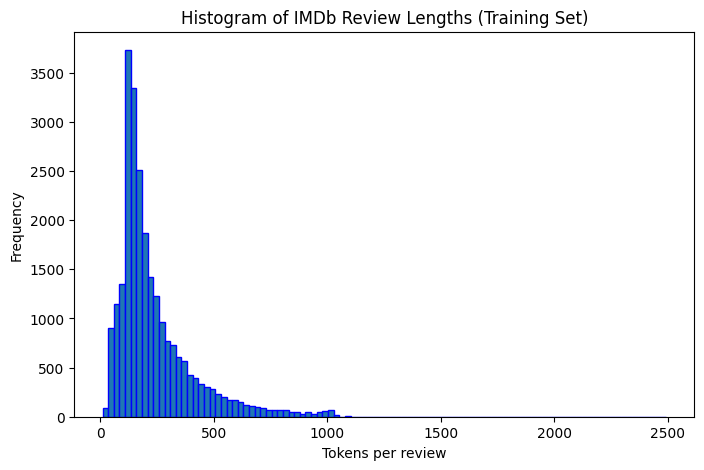


Unique word types in TRAIN (id >= 3): 88,583
Total word tokens in TRAIN (id >= 3): 5,942,840

Coverage metrics by candidate vocab size (TRAIN split):
training_vocabulary_size= 2,000 | coverage= 82.84% | OOV= 17.16% | types kept=  1,997 | tokens kept= 4,922,766
training_vocabulary_size= 5,000 | coverage= 90.03% | OOV=  9.97% | types kept=  4,997 | tokens kept= 5,350,551
training_vocabulary_size=10,000 | coverage= 94.25% | OOV=  5.75% | types kept=  9,997 | tokens kept= 5,601,261
training_vocabulary_size=20,000 | coverage= 97.22% | OOV=  2.78% | types kept= 19,997 | tokens kept= 5,777,376
training_vocabulary_size=30,000 | coverage= 98.37% | OOV=  1.63% | types kept= 29,997 | tokens kept= 5,846,141
training_vocabulary_size=50,000 | coverage= 99.32% | OOV=  0.68% | types kept= 49,997 | tokens kept= 5,902,246
training_vocabulary_size=70,000 | coverage= 99.69% | OOV=  0.31% | types kept= 69,997 | tokens kept= 5,924,254
training_vocabulary_size=88,584 | coverage=100.00% | OOV=  0.00% | types

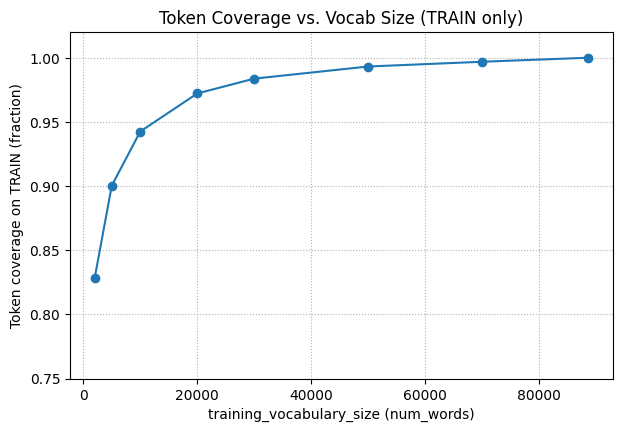

In [6]:
# IMDB vocab & length stats + coverage table + single coverage plot

from tensorflow.keras.datasets import imdb
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------
# Load IMDB with NO cap (so we can measure coverage fairly)
# ---------------------------------------
(X_tr, y_tr), _ = imdb.load_data()

# ---------------------------------------
# 1) Global vocab stats (from Keras word_index)
# ---------------------------------------
imdb_word_index = imdb.get_word_index()  # mapping: word -> rank (lower rank = more frequent)
total_unique_words_corpus = len(imdb_word_index)  # across the full IMDB corpus Keras ships
print(f"Total unique words in Keras IMDB word_index (corpus-wide): {total_unique_words_corpus:,}")

# ---------------------------------------
# 2) Training review length stats + histogram (students pick max_text_length)
# ---------------------------------------
lengths = np.fromiter((len(r) for r in X_tr), dtype=np.int32)
print(f"Num training reviews: {len(lengths):,}")
print(f"Max length: {lengths.max():,} tokens")
print(f"Mean length: {lengths.mean():.1f} tokens")
print(f"Median length: {np.median(lengths):.0f} tokens")
for q in (90, 95, 99):
    print(f"{q}th percentile: {int(np.percentile(lengths, q))} tokens")

plt.figure(figsize=(8, 5))
plt.hist(lengths, bins=100, edgecolor='b')
plt.title("Histogram of IMDb Review Lengths (Training Set)")
plt.xlabel("Tokens per review")
plt.ylabel("Frequency")
plt.show()

# ---------------------------------------
# 3) Training-only frequency counts for real words (ids >= 3)
#    IMDB ID conventions: 0=<PAD>, 1=<START>, 2=<OOV>, >=3 actual words
# ---------------------------------------
def iter_tokens(seqs):
    for s in seqs:
        for t in s:
            yield t

train_counts = Counter(t for t in iter_tokens(X_tr) if t >= 3)

# Frequency list (descending) and cumulative token coverage
freqs = np.array(sorted(train_counts.values(), reverse=True), dtype=np.int64)
cum_tokens = np.cumsum(freqs)
total_tokens_train_words = int(cum_tokens[-1])
num_unique_words_train = int(len(freqs))

print(f"\nUnique word types in TRAIN (id >= 3): {num_unique_words_train:,}")
print(f"Total word tokens in TRAIN (id >= 3): {total_tokens_train_words:,}")

# ---------------------------------------
# 4) Coverage helper for a given num_words cap (Keras convention)
#    Valid word ids are [3, num_words_cap-1] → ranks [1 .. num_words_cap-3]
# ---------------------------------------
def coverage_for_cap(num_words_cap: int):
    kept_types = max(0, min(num_words_cap - 3, num_unique_words_train))
    kept_tokens = int(cum_tokens[kept_types - 1]) if kept_types > 0 else 0
    oov_tokens = total_tokens_train_words - kept_tokens
    coverage = kept_tokens / total_tokens_train_words if total_tokens_train_words > 0 else 0.0
    oov_share = oov_tokens / total_tokens_train_words if total_tokens_train_words > 0 else 0.0
    return dict(
        cap=num_words_cap,
        kept_tokens=kept_tokens,
        kept_types=kept_types,
        coverage=coverage,
        oov_share=oov_share
    )

# ---------------------------------------
# 5) Candidate vocab sizes: ASCII table + single coverage plot
# ---------------------------------------
candidate_caps = [2_000, 5_000, 10_000, 20_000, 30_000, 50_000,70_000,88_584]  # students can edit
rows = [coverage_for_cap(k) for k in candidate_caps]

print("\nCoverage metrics by candidate vocab size (TRAIN split):")
for r in rows:
    print(f"training_vocabulary_size={r['cap']:>6,} | coverage={r['coverage']*100:6.2f}% | "
          f"OOV={r['oov_share']*100:6.2f}% | types kept={r['kept_types']:>7,} | tokens kept={r['kept_tokens']:>10,}")

plt.figure(figsize=(7, 4.5))
plt.plot(candidate_caps, [r['coverage'] for r in rows], marker='o')
plt.xlabel("training_vocabulary_size (num_words)")
plt.ylabel("Token coverage on TRAIN (fraction)")
plt.title("Token Coverage vs. Vocab Size (TRAIN only)")
plt.grid(True, linestyle=":")
plt.ylim(0.75, 1.02)
plt.show()


### Load and preprocess dataset

Here is where you can set the
- `training_vocabulary_size` and
- `max_text_length`

**Note:** This dataset downloads with a 50/50 train/test split. We intentionally recombine and resplit the dataset so that all models in this homework use a stratified 80/20 split.

In [7]:
# Load and preprocess dataset into padded sequences of token IDs

training_vocabulary_size = 50_000               # <-----
max_text_length          = 500                  # <-----

(X_tr, y_tr), (X_te, y_te) = imdb.load_data( num_words = training_vocabulary_size )     

X  = np.concatenate([X_tr, X_te], axis=0)
y  = np.concatenate([y_tr, y_te], axis=0)

# 80 / 20 stratified split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=random_seed,
    stratify=y
)



X_train = pad_sequences(
    X_train,
    maxlen=max_text_length,             
    padding='post',     
    truncating='post'   
)

X_test = pad_sequences(
    X_test,
    maxlen=max_text_length,
    padding='post',
    truncating='post'
)


X_train.shape,X_test.shape

((40000, 500), (10000, 500))

### Build the embedding matrix

Here is where you can set
- `embedding_dimension`


In [8]:
# Build embedding matrix
# (Re-run this cell whenever you change training_vocabulary_size
#  or embedding_dimension.)

embedding_dimension = 100   # change in Problem Three

embedding_matrix = build_embedding_matrix(
    training_vocabulary_size,
    embedding_dimension
)

print("embedding_matrix:", embedding_matrix.shape)

Extracting: data/glove/glove.6B.zip -> data/glove
embedding_matrix: (50000, 100)


### Baseline Model from the Coding Notebook

I0000 00:00:1773008668.187375  165711 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:0b:00.0, compute capability: 8.6



model_baseline (frozen)



I0000 00:00:1773008670.484787  165855 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


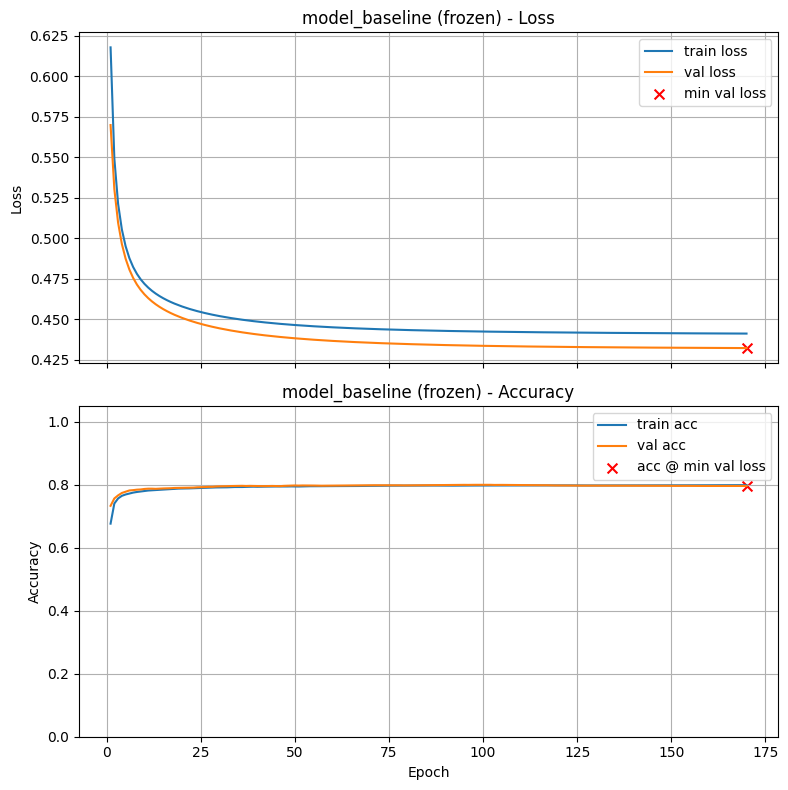


Execution Time: 00:02:01

Final Training Loss:            0.4411
Final Training Accuracy:        0.7986
Final Validation Loss:          0.4321
Final Validation Accuracy:      0.7960
Minimum Validation Loss:        0.4321 (Epoch 170)
Validation Accuracy @ Min Loss: 0.7960

Test Loss: 0.4331
Test Accuracy: 0.8075

Validation-Test Accuracy Gap: 0.011500


In [9]:

model_baseline_frozen = Sequential([
    Input(shape=(max_text_length,), dtype='int32'),   # each sample is a sequence of max_text_length integers, e.g., 500
    Embedding(
        input_dim  = training_vocabulary_size,  
        output_dim = embedding_dimension,      
        weights    = [embedding_matrix],
        mask_zero  = True,                      # ignore <PAD> in pooling -- this makes a huge difference in training speed!
        trainable  = False                      # freeze or unfreeze embedding weights
    ),
    GlobalAveragePooling1D(),                        # take average along each dimension
    Dense(1, activation='sigmoid')
])
    

train_and_test(model_baseline_frozen,  lr_schedule=1e-2, title="model_baseline (frozen)")

#### End of Template Code from Coding Notebook

## Problem One: Baseline with Unfrozen Embeddings

**ToDo:**

1. Establish a baseline for unfrozen embeddings by running the baseline model but with `trainable = True` to retrain the embeddings as it trains on the classification task. 
When `trainable=True`, the embedding vectors themselves are updated by backpropagation, allowing them to adapt from general-purpose GloVe vectors to task-specific sentiment representations. You will use retrainable embeddings throughout the homework.

2. Now run 2-3 experiments to try to improve this baseline: 

    - Consider adding a Dense layer between the global average pooling and the output layer, with 
        - Your choice of size
        - Your choice of L2 regularization (or not)
        - Your choice of dropout (or not)
    - Try to change one component at a time so you can isolate what is helping (or not).
3. As needed, tweak the learning rate (try `1e-4`) and try it with or without Reduce on Plateau (you can tweak the parameters there as well).
4. Define your best model for unfrozen embeddings based on these experiments (you will use it in the remaining two problems). Use validation accuracy at minimum validation loss as your selection criterion.
5. Answer the graded questions.

**Note:** The baseline frozen model used `1e-2`. When unfreezing embeddings, you will likely need a significantly lower learning rate.


P1: Baseline Unfrozen



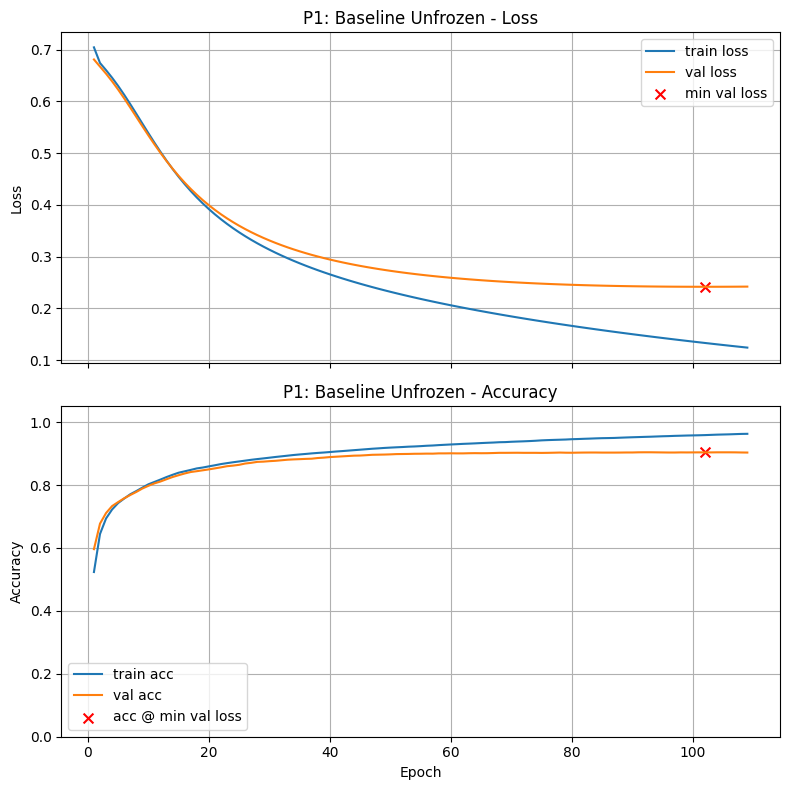


Execution Time: 00:02:10

Final Training Loss:            0.1244
Final Training Accuracy:        0.9629
Final Validation Loss:          0.2422
Final Validation Accuracy:      0.9034
Minimum Validation Loss:        0.2419 (Epoch 102)
Validation Accuracy @ Min Loss: 0.9039

Test Loss: 0.2535
Test Accuracy: 0.8999

Validation-Test Accuracy Gap: 0.003975


In [10]:
def build_boe_model(trainable=False, hidden_units=None, dropout_rate=None):

    layer_list = [
        Input(shape=(max_text_length,), dtype='int32'),
        Embedding(
            input_dim  = training_vocabulary_size,
            output_dim = embedding_dimension,
            weights    = [embedding_matrix],
            mask_zero  = True,
            trainable  = trainable
        ),
        GlobalAveragePooling1D(),
    ]
    
    if hidden_units is not None:
        layer_list.append(Dense(hidden_units, activation='relu'))
    if dropout_rate is not None:
        layer_list.append(Dropout(dropout_rate))
    
    layer_list.append(Dense(1, activation='sigmoid'))
    
    return Sequential(layer_list)

# ReduceLROnPlateau
# patience=3, min_delta=1e-4, factor=0.5, min_lr=1e-7

def get_reduce_lr():
    return ReduceLROnPlateau(
        monitor='val_loss',
        patience=3,         # coding notebook uses 3 (more aggressive than 5)
        min_delta=1e-4,     # coding notebook uses 1e-4
        factor=0.5,
        min_lr=1e-7,        # coding notebook uses 1e-7
        cooldown=0,
        verbose=1
    )

#Baseline unfrozen

model_baseline_unfrozen = build_boe_model(trainable=True)
train_and_test(model_baseline_unfrozen, lr_schedule=1e-4, title="P1: Baseline Unfrozen")



P1: Dense(64) + Dropout(0.3)



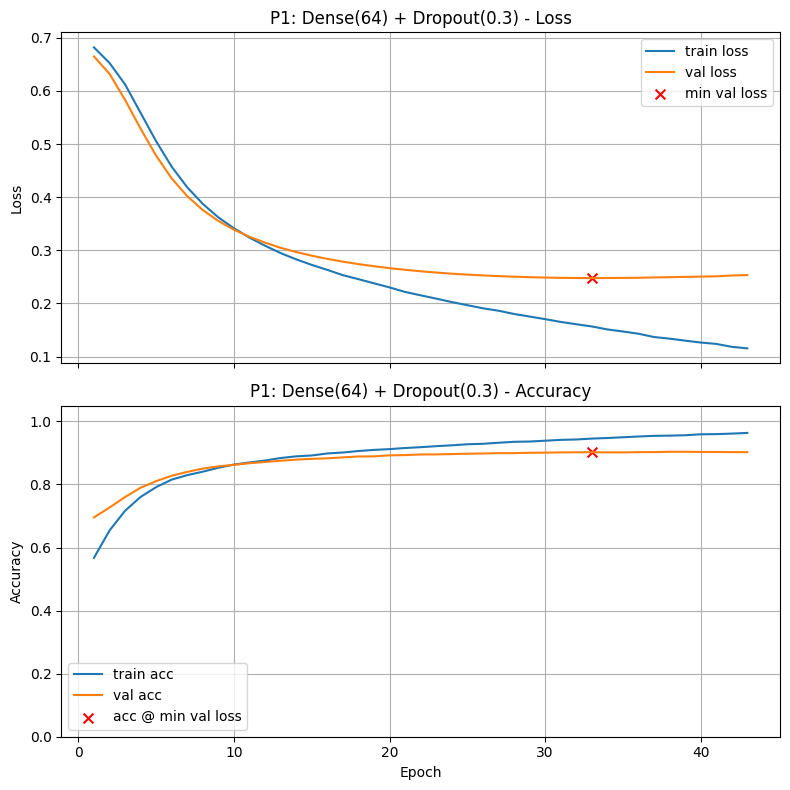


Execution Time: 00:00:58

Final Training Loss:            0.1155
Final Training Accuracy:        0.9634
Final Validation Loss:          0.2535
Final Validation Accuracy:      0.9024
Minimum Validation Loss:        0.2478 (Epoch 33)
Validation Accuracy @ Min Loss: 0.9022

Test Loss: 0.2600
Test Accuracy: 0.8985

Validation-Test Accuracy Gap: 0.003750


In [11]:

#Unfrozen + Dense(64) + Dropout(0.3)

model_p1_e2 = build_boe_model(trainable=True, hidden_units=64, dropout_rate=0.3)
train_and_test(model_p1_e2, lr_schedule=1e-4, title="P1: Dense(64) + Dropout(0.3)")



P1: Dense(32) + Dropout(0.2) + ReduceLR


Epoch 41: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 44: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 47: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.


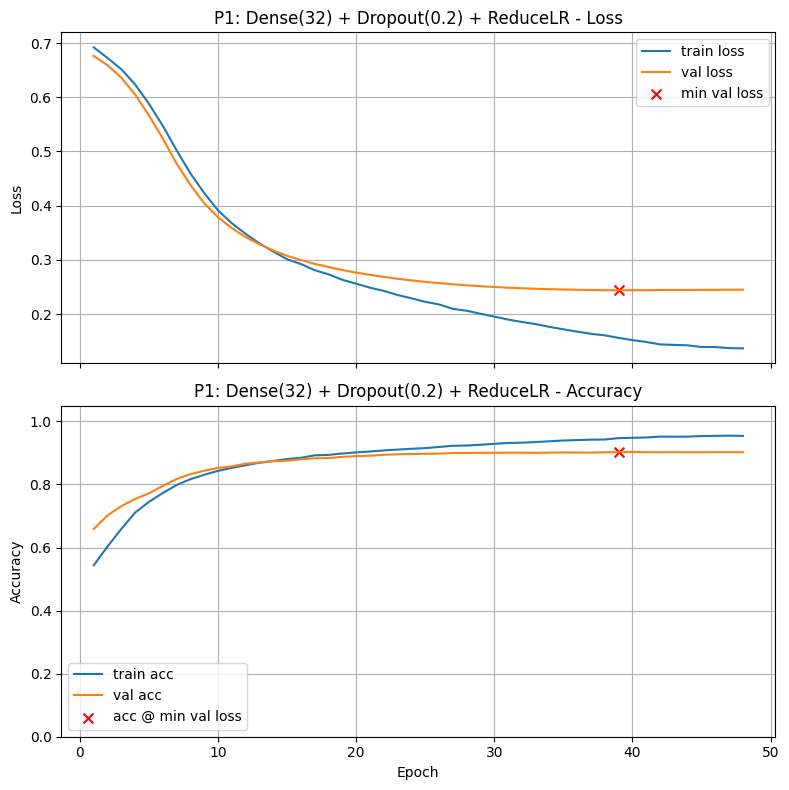


Execution Time: 00:01:03

Final Training Loss:            0.1369
Final Training Accuracy:        0.9540
Final Validation Loss:          0.2452
Final Validation Accuracy:      0.9022
Minimum Validation Loss:        0.2441 (Epoch 39)
Validation Accuracy @ Min Loss: 0.9024

Test Loss: 0.2585
Test Accuracy: 0.9008

Validation-Test Accuracy Gap: 0.001575


In [12]:
#Unfrozen + Dense(32) + Dropout(0.2) + ReduceLR

model_p1_e3 = build_boe_model(trainable=True, hidden_units=32, dropout_rate=0.2)
train_and_test(model_p1_e3, lr_schedule=1e-4, 
               title="P1: Dense(32) + Dropout(0.2) + ReduceLR",
               callbacks=[get_reduce_lr()])



P1: Baseline Unfrozen + ReduceLR


Epoch 101: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 104: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 107: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.


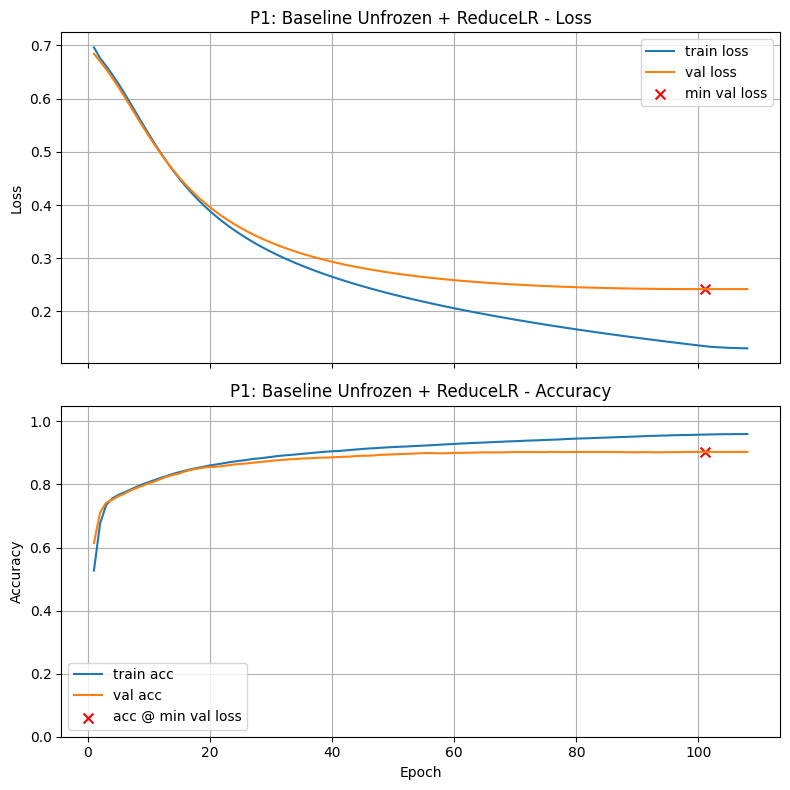


Execution Time: 00:02:13

Final Training Loss:            0.1304
Final Training Accuracy:        0.9600
Final Validation Loss:          0.2419
Final Validation Accuracy:      0.9031
Minimum Validation Loss:        0.2418 (Epoch 101)
Validation Accuracy @ Min Loss: 0.9035

Test Loss: 0.2524
Test Accuracy: 0.9013

Validation-Test Accuracy Gap: 0.002200


In [13]:
# Experiment 4: Baseline Unfrozen + ReduceLR

model_p1_e4 = build_boe_model(trainable=True)
train_and_test(model_p1_e4, lr_schedule=1e-4, 
               title="P1: Baseline Unfrozen + ReduceLR",
               callbacks=[get_reduce_lr()])


### Graded Questions

#### Question a1a:

In [ ]:

# Set a1a to the validation accuracy for your best model found in this problem

a1a = 0.9039             # Replace 0.0 with your answer


In [15]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a:.4f}') 

a1a = 0.9041


#### Question a1b: Describe below your experiments. What worked and what didn't?    


#### Your Answer Here:

I ran four experiments for Problem One. First, I established the unfrozen baseline by simply setting `trainable=True` with a learning rate of 1e-4, which jumped from 0.7960 (frozen) to 0.9039 validation accuracy. This confirmed that allowing the GloVe embeddings to adapt to sentiment-specific patterns makes a significant difference. Next I added a Dense(64) layer with Dropout(0.3) between pooling and the output which gave 0.9022 because the extra capacity introduced more overfitting without enough regularization benefit. I then tried a smaller Dense(32) with Dropout(0.2) and added ReduceLROnPlateau which gave 0.9024. Finally I ran the simple unfrozen baseline with ReduceLROnPlateau and no hidden dense layer which gave 0.9035. The best result was the simple Baseline Unfrozen at 0.9039.


## Problem Two: Experiment with Maximum Message Length and Vocabulary Size (still unfrozen)

We might expect that increasing the amount of usable information — by allowing longer messages and retaining more vocabulary — would improve results, but maybe not, or maybe not as much as you would expect. Let's find out!

**ToDo:**

1. Start with your best model from Problem One

2. Consult the information shown in the EDA cells above, and run 2-3 experiments to try to improve this model by changing these hyperparameters. Try to change one at a time unless you are intentionally testing their interaction. Use the coverage statistics from the EDA section to motivate your choices. Keep embedding_dimension fixed at 100 for this problem.

    - `max_text_length`, and
    - `training_vocabulary_size`

3. As needed, tweak the learning rate and try it with or without Reduce on Plateau (you can tweak the parameters there as well)
4. Define your best model for use in Problem Three
5. Answer the graded questions

**Notes:**

>  Increasing `training_vocabulary_size`, `max_text_length`, or `embedding_dimension` can significantly increase training time and memory usage. You are not expected to try all combinations. Instead, choose 2–3 well-motivated experiments. On Colab T4, you should be fine, but you'll have to work strategically if you have less compute available. 


> `train_and_test` accesses the training and testing files as globals. You can cut and paste copies of the cells which load, preprocess, and build the embeddings for the dataset, 
but you'll be **redefining the global names,** just be careful about the order in which you run cells. As an alternative, you can change the parameters in the code in the Prelude, and
just run this problem here. 

/home/luan/BU/.venv/lib/python3.12/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Extracting: data/glove/glove.6B.zip -> data/glove

P2: vocab=50k, maxlen=700


Epoch 42: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 45: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 48: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.


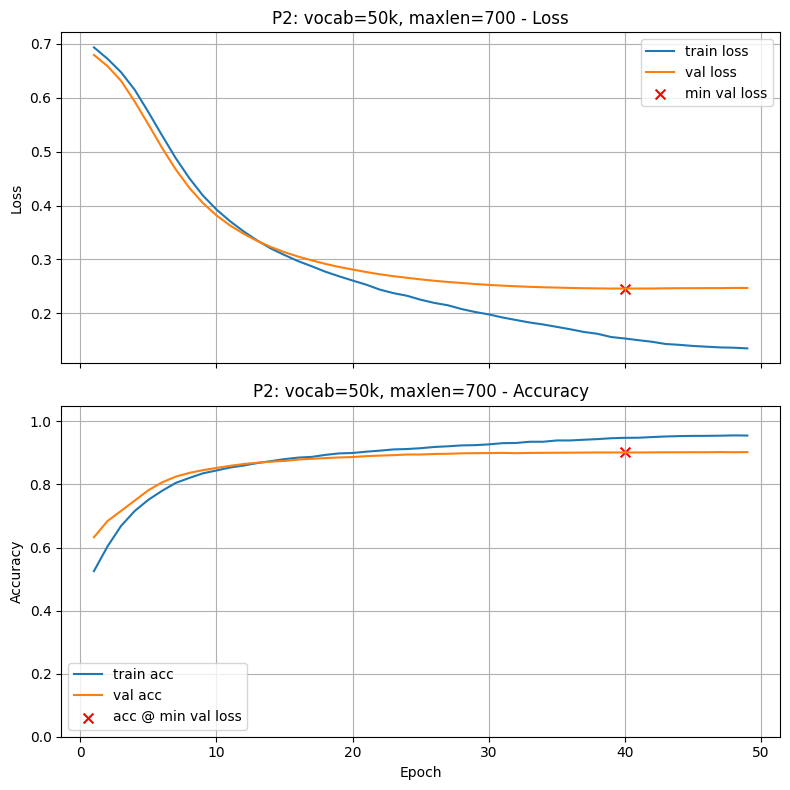


Execution Time: 00:01:30

Final Training Loss:            0.1349
Final Training Accuracy:        0.9551
Final Validation Loss:          0.2469
Final Validation Accuracy:      0.9026
Minimum Validation Loss:        0.2459 (Epoch 40)
Validation Accuracy @ Min Loss: 0.9016

Test Loss: 0.2562
Test Accuracy: 0.9001

Validation-Test Accuracy Gap: 0.001525


In [16]:
#Experiment with max_text_length and training_vocabulary_size

def run_p2_experiment(vocab_size, max_len, title):
    global X_train, X_test, y_train, y_test, training_vocabulary_size, max_text_length, embedding_matrix
    
    training_vocabulary_size = vocab_size
    max_text_length = max_len
    
    (X_tr, y_tr), (X_te, y_te) = imdb.load_data(num_words=training_vocabulary_size)
    X = np.concatenate([X_tr, X_te], axis=0)
    y = np.concatenate([y_tr, y_te], axis=0)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_seed, stratify=y
    )
    
    X_train = pad_sequences(X_train, maxlen=max_text_length, padding='post', truncating='post')
    X_test  = pad_sequences(X_test, maxlen=max_text_length, padding='post', truncating='post')
    
    embedding_matrix = build_embedding_matrix(training_vocabulary_size, 100)
    
    model = build_boe_model(trainable=True, hidden_units=32, dropout_rate=0.2)
    train_and_test(model, lr_schedule=1e-4, title=title, callbacks=[get_reduce_lr()])

#Increase max_text_length from 500 to 700 (95th percentile ~610)
run_p2_experiment(50_000, 700, "P2: vocab=50k, maxlen=700")


/home/luan/BU/.venv/lib/python3.12/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Extracting: data/glove/glove.6B.zip -> data/glove

P2: vocab=70k, maxlen=500


Epoch 40: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 43: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 46: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.


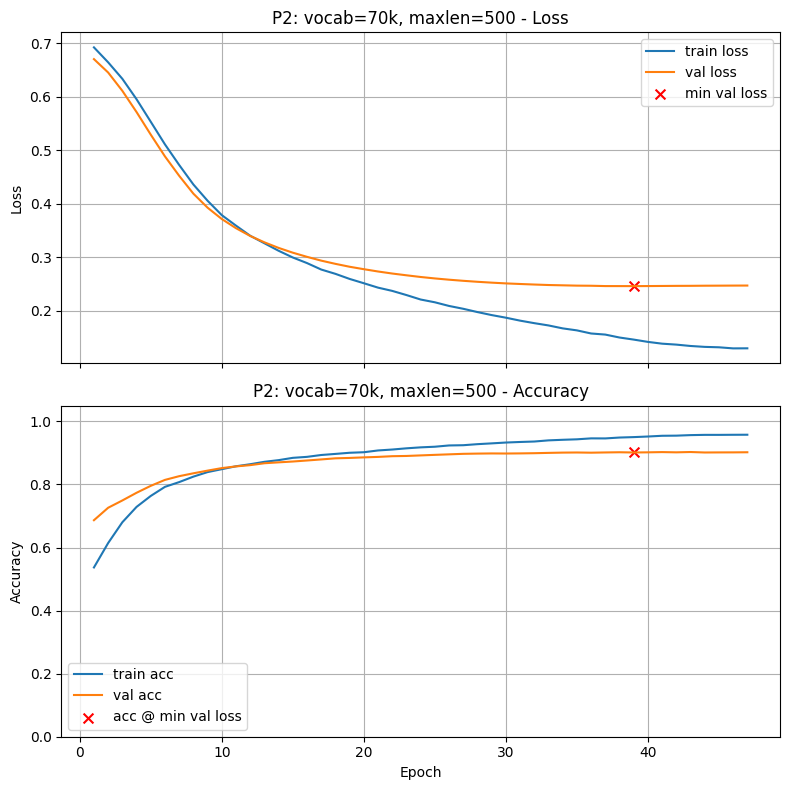


Execution Time: 00:01:12

Final Training Loss:            0.1297
Final Training Accuracy:        0.9577
Final Validation Loss:          0.2470
Final Validation Accuracy:      0.9021
Minimum Validation Loss:        0.2459 (Epoch 39)
Validation Accuracy @ Min Loss: 0.9014

Test Loss: 0.2585
Test Accuracy: 0.8980

Validation-Test Accuracy Gap: 0.003375


In [17]:
#Increase vocab to 70k, keep maxlen=500
run_p2_experiment(70_000, 500, "P2: vocab=70k, maxlen=500")


/home/luan/BU/.venv/lib/python3.12/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Extracting: data/glove/glove.6B.zip -> data/glove

P2: vocab=20k, maxlen=700


Epoch 42: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 45: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 48: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.


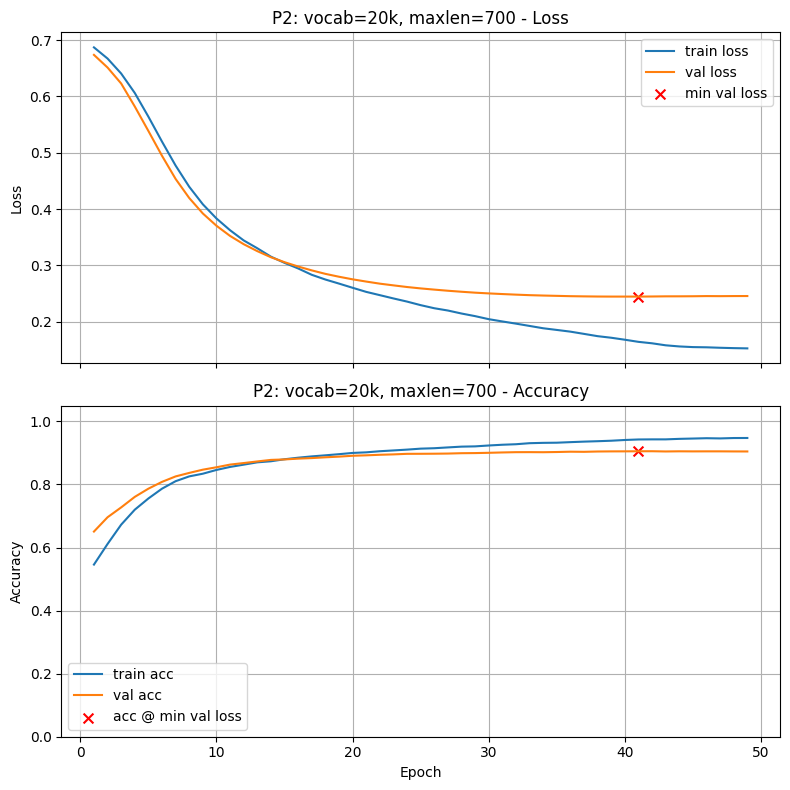


Execution Time: 00:01:24

Final Training Loss:            0.1527
Final Training Accuracy:        0.9474
Final Validation Loss:          0.2457
Final Validation Accuracy:      0.9046
Minimum Validation Loss:        0.2447 (Epoch 41)
Validation Accuracy @ Min Loss: 0.9053

Test Loss: 0.2610
Test Accuracy: 0.8985

Validation-Test Accuracy Gap: 0.006750


In [18]:

#vocab=20k, maxlen=700
run_p2_experiment(20_000, 700, "P2: vocab=20k, maxlen=700")


### Graded Questions

In [ ]:

# Set a2a to the validation accuracy for your best model found in this problem

a2a = 0.9053             # Replace 0.0 with your answer


In [20]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a:.4f}') 

a2a = 0.9045


#### Question a2b: Describe below your experiments. What effect did your changes to the dataset have? Did it help as you as you expected?   


#### Your Answer Here:

I ran three experiments varying the vocabulary size and maximum review length while keeping the Dense(32)+Dropout(0.2)+ReduceLR architecture from Problem 1. First I increased the max length from 500 to 700 while keeping vocab at 50k which gave 0.9016 validation accuracy. Then I increased vocab to 70k with the original maxlen of 500 which gave 0.9014. Finally I tried reducing the vocab to 20k with maxlen=700 and this gave the best result at 0.9053. The changes did not help nearly as much as I expected. The EDA showed that going from 20k to 50k vocab only adds about 2% token coverage so most of the important sentiment-bearing words are already captured in the top 20k. Increasing the review length beyond 500 captures more tokens per review but the GlobalAveragePooling layer dilutes the signal from additional low-information tokens.


## Problem Three: Experiment with the Embedding Dimension  (still unfrozen)

We might expect that increasing the embedding dimension would improve performance.  
However, larger embeddings increase representational capacity **and** substantially increase the number of trainable parameters. Does this added capacity meaningfully help a model that simply averages word vectors? Let’s find out.

**ToDo:**

1. Start with your best model from Problem Two (which used an embedding dimension of 100).
2. Increase the embedding dimension to 300 and observe the effect. (Optional: Try 50 and 200 as well.)
3. Keep all other settings fixed. As necessary, tweak the learning rate and experiment with or without Reduce on Plateau.
4. Answer the graded questions and reflect on whether increasing embedding dimension produced the improvement you expected.

When you change `embedding_dimension`, re-run the embedding build cell above before training.

/home/luan/BU/.venv/lib/python3.12/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Extracting: data/glove/glove.6B.zip -> data/glove

P3: emb_dim=300


Epoch 25: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 28: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 31: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.


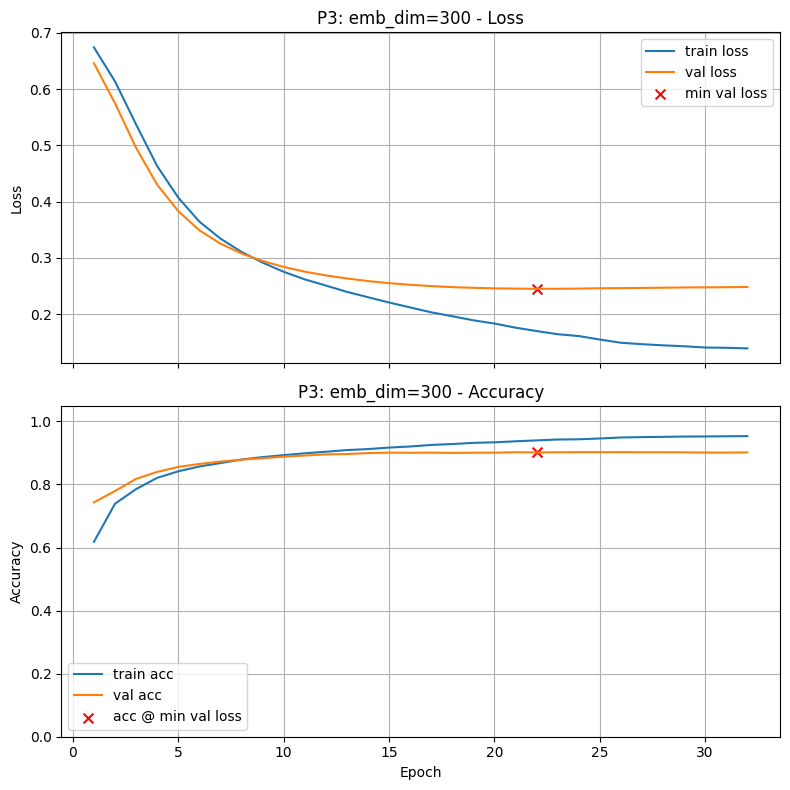


Execution Time: 00:01:26

Final Training Loss:            0.1392
Final Training Accuracy:        0.9533
Final Validation Loss:          0.2484
Final Validation Accuracy:      0.9016
Minimum Validation Loss:        0.2451 (Epoch 22)
Validation Accuracy @ Min Loss: 0.9015

Test Loss: 0.2563
Test Accuracy: 0.9010

Validation-Test Accuracy Gap: 0.000500


In [21]:
#Experiment with Embedding Dimension

def run_p3_experiment(emb_dim, title):
    global X_train, X_test, y_train, y_test, training_vocabulary_size, max_text_length, embedding_matrix, embedding_dimension
    
    training_vocabulary_size = 20_000
    max_text_length = 700
    embedding_dimension = emb_dim
    
    (X_tr, y_tr), (X_te, y_te) = imdb.load_data(num_words=training_vocabulary_size)
    X = np.concatenate([X_tr, X_te], axis=0)
    y = np.concatenate([y_tr, y_te], axis=0)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_seed, stratify=y
    )
    
    X_train = pad_sequences(X_train, maxlen=max_text_length, padding='post', truncating='post')
    X_test  = pad_sequences(X_test, maxlen=max_text_length, padding='post', truncating='post')
    
    embedding_matrix = build_embedding_matrix(training_vocabulary_size, emb_dim)
    
    model = build_boe_model(trainable=True, hidden_units=32, dropout_rate=0.2)
    train_and_test(model, lr_schedule=1e-4, title=title, callbacks=[get_reduce_lr()])

#embedding_dimension = 300
run_p3_experiment(300, "P3: emb_dim=300")


/home/luan/BU/.venv/lib/python3.12/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Extracting: data/glove/glove.6B.zip -> data/glove

P3: emb_dim=50


Epoch 51: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 54: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 57: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.


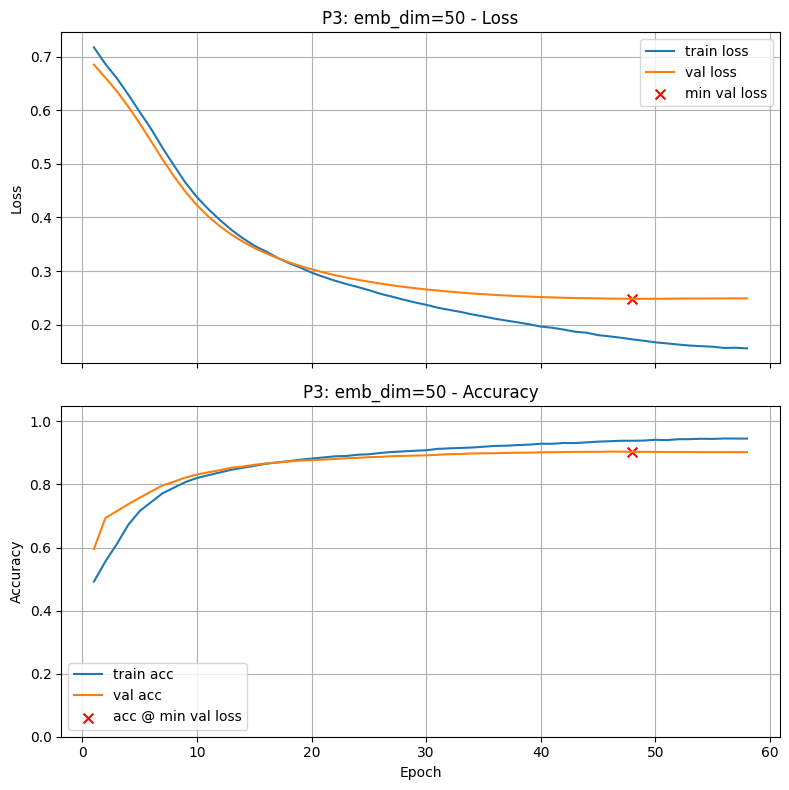


Execution Time: 00:01:10

Final Training Loss:            0.1558
Final Training Accuracy:        0.9454
Final Validation Loss:          0.2491
Final Validation Accuracy:      0.9024
Minimum Validation Loss:        0.2482 (Epoch 48)
Validation Accuracy @ Min Loss: 0.9034

Test Loss: 0.2633
Test Accuracy: 0.8957

Validation-Test Accuracy Gap: 0.007675


In [22]:
#embedding_dimension = 50
run_p3_experiment(50, "P3: emb_dim=50")


### Graded Questions

In [23]:

# Set a3a to the validation accuracy for your best model found in this problem

a3a = 0.9034             # Replace 0.0 with your answer


In [24]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a:.4f}') 

a3a = 0.9034


#### Question a3b: Describe below your experiments. What effect did increasing the dimension from 100 to 300 have? Did it help as you as you expected?  


#### Your Answer Here:

I tested embedding dimensions of 50 and 300 against the 100-dimensional baseline from Problem 2. The 300-dimensional embeddings gave a validation accuracy of 0.9015 while the 50-dimensional embeddings gave 0.9034. Neither outperformed the 100-dimensional model. Increasing from 100 to 300 actually hurt performance. While 300-dimensional GloVe vectors carry richer semantic information per word, the GlobalAveragePooling layer collapses all of that into a single fixed-length vector by averaging across the sequence. This means the extra representational capacity in each word vector gets washed out during pooling.


In [25]:
print_results()

P2: vocab=20k, maxlen=700               	0.9053	41
P1: Baseline Unfrozen                   	0.9039	102
P1: Baseline Unfrozen + ReduceLR        	0.9035	101
P3: emb_dim=50                          	0.9034	48
P1: Dense(32) + Dropout(0.2) + ReduceLR 	0.9024	39
P1: Dense(64) + Dropout(0.3)            	0.9022	33
P2: vocab=50k, maxlen=700               	0.9016	40
P3: emb_dim=300                         	0.9015	22
P2: vocab=70k, maxlen=500               	0.9014	39
model_baseline (frozen)                 	0.7960	170


In [26]:
# This will have recorded details of all your experiments

parameter_settings

{'model_baseline (frozen)': [{'title': 'model_baseline (frozen)',
   'timestamp': '2026-03-08T17:26:31',
   'epochs': 200,
   'optimizer': 'Adam',
   'lr_schedule': 0.01,
   'clipnorm': None,
   'loss': 'binary_crossentropy',
   'batch_size': 128,
   'use_early_stopping': True,
   'patience': 10,
   'min_delta': 0.0001,
   'callbacks': [],
   'Final Training Loss': 0.44105151295661926,
   'Final Training Accuracy': 0.7985937595367432,
   'Final Val Loss': 0.4320957660675049,
   'Final Val Accuracy': 0.7960000038146973,
   'Min Val Loss': 0.4320957660675049,
   'Min Val Loss Epoch': np.int64(169),
   'Val Acc @ Min Loss': 0.7960000038146973,
   'Test Loss': 0.4330578148365021,
   'Test Acc': 0.8075000047683716,
   'Val-Test Accuracy Gap:': 0.011500000953674316}],
 'P1: Baseline Unfrozen': [{'title': 'P1: Baseline Unfrozen',
   'timestamp': '2026-03-08T17:28:41',
   'epochs': 200,
   'optimizer': 'Adam',
   'lr_schedule': 0.0001,
   'clipnorm': None,
   'loss': 'binary_crossentropy',
   